Data du rheometre de Y16SE4 a 1mM:
- 27/01/2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

π = np.pi
def fmmGp(ω, V, G, α, β):
    '''Elastic modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.cos(π*α/2) + Vo**2 * Go * np.cos(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmGpp(ω, V, G, α, β):
    '''Viscous modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.sin(π*α/2) + Vo**2 * Go * np.sin(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmtandelta(ω, V, G, α, β):
    '''Loss tangent of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go * np.sin(π*α/2) + Vo * np.sin(π*β/2)
    )/(
        Go * np.cos(π*α/2) + Vo * np.cos(π*β/2)
    )

def mmtandelta(ω, k, τ):
    '''Loss tangent of the Maxwell Model'''
    return 1/(τ * ω)
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )

# sample 27/01/2025

Text(0.5, 1.0, 'after annealing 90C, wait 5min')

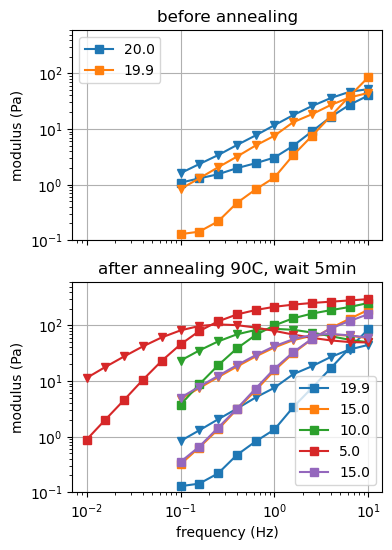

In [5]:
os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250127")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

def get_moduli2(file):
    filename = f'Y4-FS-{file}.tsv'
    data = np.loadtxt(filename, skiprows=2, delimiter='\t')
    Temp = data[0,6]
    freq, Gp, Gpp = np.transpose(data[:,2:5])
    mask = (Gp != 0) & (Gpp != 0)
    freq, Gp, Gpp = freq[mask], Gp[mask], Gpp[mask]
    return Temp, freq, Gp, Gpp

def plot_moduli2(n, ax, colors=colors):
    c = 0
    lines = []
    for i in n:
        T, freq, Gp, Gpp = get_moduli2(i)
        line, = ax.plot(freq, Gp, marker='s', color=colors[c%len(n)], linestyle='-', label=T)
        ax.plot(freq, Gpp, marker='v', color=line.get_color(), linestyle='-')
        lines.append(line)
        c += 1
    return lines

fig1, ax1 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [1,2]
plot_moduli2(n, ax1[0])

n = [3,4,5,6,7]
plot_moduli2(n, ax1[1])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend()
    ax.grid()
    ax.set_ylim(0.1,6e2)
ax1[1].set_xlabel('frequency (Hz)')
ax1[0].set_title('before annealing')
ax1[1].set_title('after annealing 90C, wait 5min')

Text(0.5, 1.0, 'control curves')

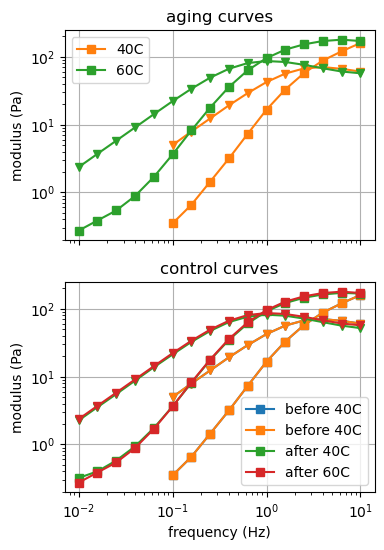

In [7]:
# aging test
fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [9,11]
lines1 = plot_moduli2(n, ax2[0], colors[1:])
labels1 = ['40C', '60C']

n = [7,8,10,12]
lines2 = plot_moduli2(n, ax2[1])
labels2 = ['before 40C', 'before 40C', 'after 40C', 'after 60C']

for ax in ax2:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.grid()
    # ax.set_ylim(1,2e3)
ax2[1].set_xlabel('frequency (Hz)')
ax2[0].legend(lines1, labels1)
ax2[1].legend(lines2, labels2)
ax2[0].set_title('aging curves')
ax2[1].set_title('control curves')

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ajiye\AppData\Local\Temp\ipykernel_76380\2312214172.py:14: SyntaxWarning: invalid escape sequence '\%'
  line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')


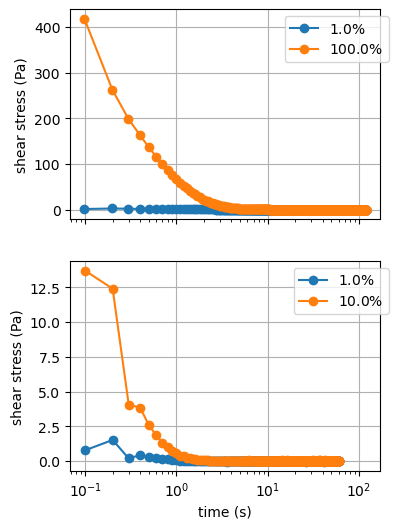

In [13]:
def get_strain(file):
    filename = f'Y4-strain-{file}.tsv'
    data = np.genfromtxt(filename, skip_header=2, delimiter='\t', usecols=(0,6,7,8), dtype=float)
    Temp = data[0,1]
    time = data[:,0]
    gamma, tau = np.transpose(data[:,2:])
    return Temp, time, gamma, tau

def plot_strain(n, ax):
    c = 0
    lines = []
    for i in n:
        T, time, gamma, tau = get_strain(i)
        line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')
        lines.append(line)
        c += 1
    return lines

fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [1,5]
plot_strain(n, ax2[0])

n = [7,9]
plot_strain(n, ax2[1])

ax2[1].set_xscale('log')
ax2[1].set_xlabel('time (s)')
for ax in ax2:
    ax.set_ylabel('shear stress (Pa)')
    ax.grid()
    ax.legend(bbox_to_anchor=(1.05,1))